In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('./data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
from sklearn.model_selection import train_test_split

df_copy = df
df_copy = df_copy.drop('Time', axis=1)

df_copy.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
X_features = df_copy.iloc[:, :-1]
y_label = df_copy.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X_features,
                                                    y_label,
                                                    test_size = 0.3,
                                                    random_state = 42,
                                                    stratify = y_label)

print(y_train.value_counts()/y_train.shape[0])
print(y_test.value_counts()/y_test.shape[0])

Class
0    0.998275
1    0.001725
Name: count, dtype: float64
Class
0    0.998268
1    0.001732
Name: count, dtype: float64


In [6]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def get_clf_eval(y_test, pred=None, pred_proba=None):
	confusion = confusion_matrix(y_test, pred)
	accuracy = accuracy_score(y_test, pred)
	precision = precision_score(y_test, pred)
	recall = recall_score(y_test, pred)
	f1 = f1_score(y_test, pred)
	roc_auc = roc_auc_score(y_test, pred_proba)
	print('Confusion Matrix')
	print(confusion)

	print('정확도: {0:.4f}, 정밀도: {1:4f}, 재현율: {2:4f},\
	F1: {3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

In [7]:
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
lr_pred = lr_clf.predict(X_test)
lr_pred_proba = lr_clf.predict_proba(X_test)[:, 1]

get_clf_eval(y_test, lr_pred, lr_pred_proba)

Confusion Matrix
[[85276    19]
 [   55    93]]
정확도: 0.9991, 정밀도: 0.830357, 재현율: 0.628378,	F1: 0.7154, AUC:0.9311


In [8]:
def get_model_train_eval(model,
                        ftr_train = None,
                        ftr_test = None,
                        tgt_train = None,
                        tgt_test=None):
    model.fit(ftr_train, tgt_train)
    pred = model.predict(ftr_test)
    pred_proba = model.predict_proba(ftr_test)[:, 1]
    get_clf_eval(tgt_test, pred, pred_proba)

In [9]:
from lightgbm import LGBMClassifier
lgbm_clf = LGBMClassifier(n_estimators = 1000,
                          num_leaves = 64,
                          n_jobs = -1,
                          boost_from_average = False)

get_model_train_eval(lgbm_clf,
                     ftr_train = X_train,
                     ftr_test = X_test,
                     tgt_train = y_train,
                     tgt_test = y_test)

[LightGBM] [Info] Number of positive: 344, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009148 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 199364, number of used features: 29
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

In [10]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


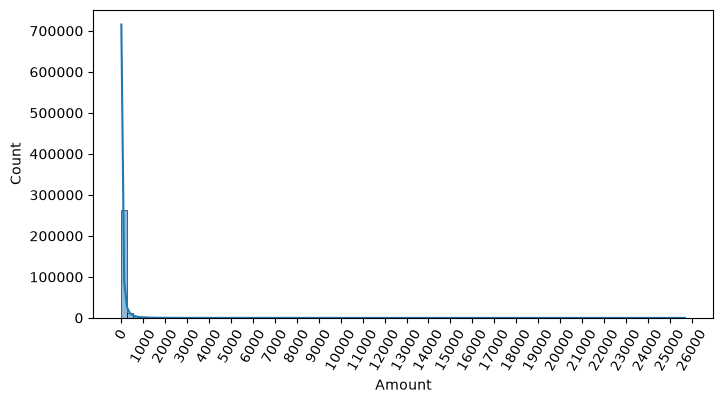

In [11]:
import seaborn as sns

plt.figure(figsize=(8, 4))
plt.xticks(range(0, 30000, 1000),
           rotation = 60)
sns.histplot(df['Amount'],
            bins = 100,
            kde = True)
plt.show()

In [12]:
from sklearn.preprocessing import StandardScaler

df_scaled = df
scaler = StandardScaler()
amount_n = scaler.fit_transform(df_scaled['Amount'].values.reshape(-1, 1))
df_scaled.insert(0, 'Amount_Scaled', amount_n)
df_scaled.drop(['Time', 'Amount'], axis =1, inplace =True)
df_scaled.head()

,Amount_Scaled,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,0.244964,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.342475,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,1.160686,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,0.140534,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,-0.073403,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


In [13]:
X_features = df_scaled.iloc[:, :-1]
y_label = df_scaled.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X_features,
                                                    y_label,
                                                    test_size = 0.3,
                                                    random_state = 42,
                                                    stratify = y_label)

In [14]:
lr_clf = LogisticRegression()
get_model_train_eval(lr_clf,
                     ftr_train = X_train,
                     ftr_test = X_test,
                     tgt_train = y_train,
                     tgt_test = y_test)

lgbm_clf = LGBMClassifier(n_estimators = 1000,
                          num_leaves = 64,
                          n_jobs = -1,
                          boost_from_average = False)

get_model_train_eval(lgbm_clf,
                     ftr_train = X_train,
                     ftr_test = X_test,
                     tgt_train = y_train,
                     tgt_test = y_test)

Confusion Matrix
[[85280    15]
 [   57    91]]
정확도: 0.9992, 정밀도: 0.858491, 재현율: 0.614865,	F1: 0.7165, AUC:0.9565
[LightGBM] [Info] Number of positive: 344, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010010 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 199364, number of used features: 29
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

In [15]:
df_log = df
amount_n = np.log1p(df_log['Amount'])
df_log.insert(0, 'Amount_Scaled', amount_n)
df_log.drop(['Time', 'Amount'], axis =1, inplace =True)
df_log.head()

KeyError: 'Amount'

In [ ]:
X_features = df_scaled.iloc[:, :-1]
y_label = df_scaled.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X_features,
                                                    y_label,
                                                    test_size = 0.3,
                                                    random_state = 42,
                                                    stratify = y_label)



lr_clf = LogisticRegression()

get_model_train_eval(lr_clf,
                     ftr_train = X_train,
                     ftr_test = X_test,
                     tgt_train = y_train,
                     tgt_test = y_test)

lgbm_clf = LGBMClassifier(n_estimators = 1000,
                          num_leaves = 64,
                          n_jobs = -1,
                          boost_from_average = False)

get_model_train_eval(lgbm_clf,
                     ftr_train = X_train,
                     ftr_test = X_test,
                     tgt_train = y_train,
                     tgt_test = y_test)

Confusion Matrix
[[85280    15]
 [   57    91]]
정확도: 0.9992, 정밀도: 0.858491, 재현율: 0.614865,	F1: 0.7165, AUC:0.9565
[LightGBM] [Info] Number of positive: 344, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010497 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 199364, number of used features: 29
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

<Axes: >

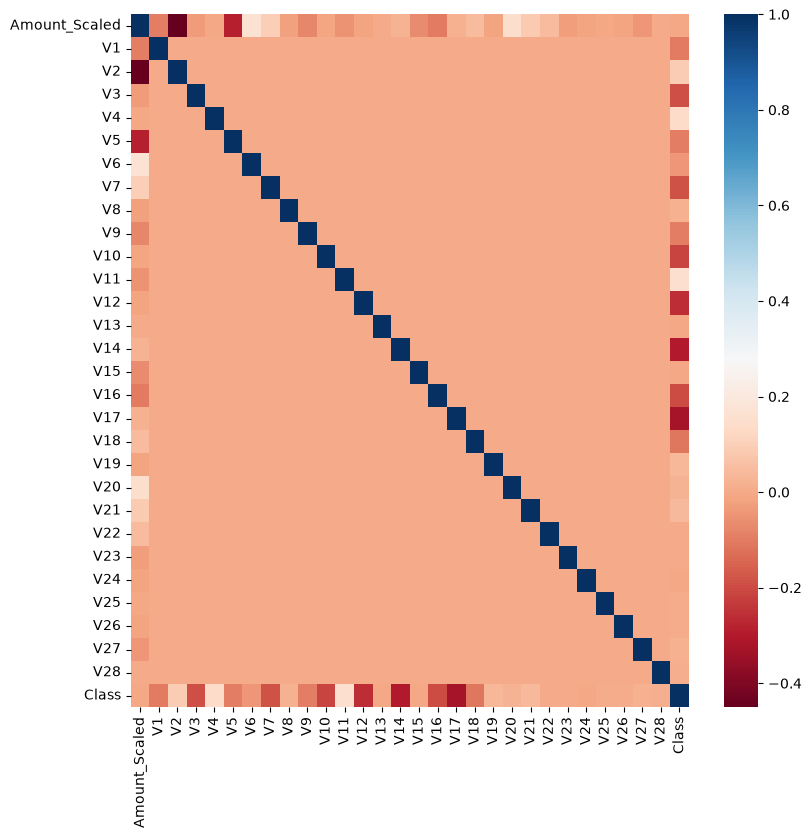

In [ ]:
import seaborn as sns

plt.figure(figsize=(9,9))
corr = df.corr()
sns.heatmap(corr, cmap='RdBu')

In [ ]:
import numpy as np

fraud = df[df['Class']==1]['V14']
quantile25 = np.percentile(fraud.values, 25)
quantile75 = np.percentile(fraud.values, 75)
iqr = quantile75 - quantile25
iqr_weight = iqr * 1.5
lowest = quantile25 - iqr_weight
highest = quantile75 + iqr_weight

outlier_index = fraud[(fraud < lowest) | (fraud > highest)].index
print(outlier_index)

Index([8296, 8615, 9035, 9252], dtype='int64')


In [ ]:
df_outlier = df
amount_n = np.log1p(df_outlier['Amount'])
df_outlier.insert(0, 'Amount_scaled', amount_n)
df_outlier.drop(['Time', 'Amount'], axis = 1, inplace=True)
df_outlier.drop(outlier_index, axis = 0, inplace = True)

In [ ]:
X_features = df_outlier.iloc[:, :-1]
y_label = df_outlier.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X_features,
                                                    y_label,
                                                    test_size = 0.3,
                                                    random_state = 42,
                                                    stratify = y_label)



lr_clf = LogisticRegression()

get_model_train_eval(lr_clf,
                     ftr_train = X_train,
                     ftr_test = X_test,
                     tgt_train = y_train,
                     tgt_test = y_test)

lgbm_clf = LGBMClassifier(n_estimators = 1000,
                          num_leaves = 64,
                          n_jobs = -1,
                          boost_from_average = False)

get_model_train_eval(lgbm_clf,
                     ftr_train = X_train,
                     ftr_test = X_test,
                     tgt_train = y_train,
                     tgt_test = y_test)

Confusion Matrix
[[85281    14]
 [   52    94]]
정확도: 0.9992, 정밀도: 0.870370, 재현율: 0.643836,	F1: 0.7402, AUC:0.9757
[LightGBM] [Info] Number of positive: 342, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009709 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 199362, number of used features: 29
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

In [19]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state = 42)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)

print(X_train.shape, y_train.shape)
print(X_train_over.shape, y_train_over.shape)
print(pd.Series(y_train).value_counts())
print(pd.Series(y_train_over).value_counts())

(199364, 29) (199364,)
(398040, 29) (398040,)
Class
0    199020
1       344
Name: count, dtype: int64
Class
0    199020
1    199020
Name: count, dtype: int64


In [20]:
lr_clf = LogisticRegression()


get_model_train_eval(lr_clf,
                     ftr_train = X_train_over,
                     ftr_test = X_test,
                     tgt_train = y_train_over,
                     tgt_test = y_test)

Confusion Matrix
[[83328  1967]
 [   18   130]]
정확도: 0.9768, 정밀도: 0.061993, 재현율: 0.878378,	F1: 0.1158, AUC:0.9676


In [35]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import precision_recall_curve

def precision_recall_curve_plot(y_test=None, pred_proba_c1=None):
    precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba_c1)
    plt.figure(figsize=(8,6))
    threshold_boundary = thresholds.shape[0]
    plt.plot(thresholds,
             precisions[0:threshold_boundary],
             linestyle = '--',
             label = 'precision')
    plt.plot(thresholds,
             recalls[0:threshold_boundary],
             linestyle = '--',
             label = 'recalls')


    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1), 2))
    plt.xlabel('Threshold Value')
    plt.ylabel('Precision and Recall Value')
    plt.legend()
    plt.grid()
    plt.show()

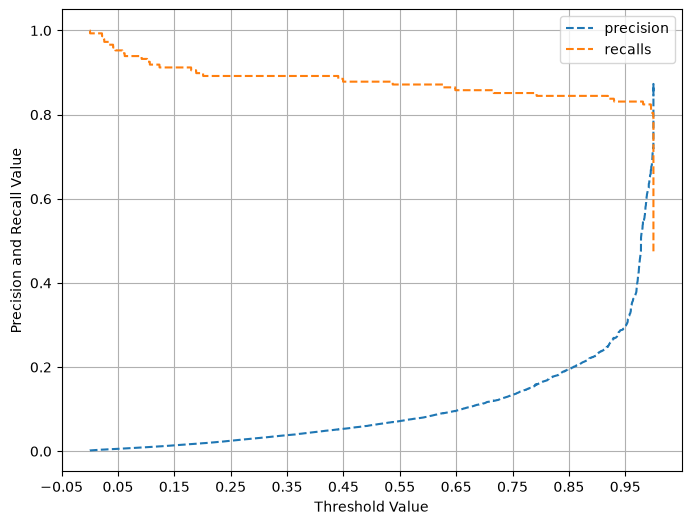

In [36]:
precision_recall_curve_plot(y_test, lr_clf.predict_proba(X_test)[:, 1])